# Stroke Precition Dataset (AVC)

**Nome:** Gabriel Figueiredo de Andrade - 11241102782

**Nome:** Nelson Braga Schiavi - 11241101950

## Introdução

Neste notebook aplicamos um **Support Vector Classifier (SVC)** com otimização de hiperparâmetros via **GridSearchCV** para prever se um paciente teve um **AVC (acidente vascular cerebral)**.

**Dataset:** [Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset).

**Arquivo:** `healthcare-dataset-stroke-data.csv` (~5.110 pacientes, 12 colunas).

## Metodologia

**SVM:** o SVM procura a fronteira (hiperplano) que separa as classes com a **maior margem possível**. Com kernels (como o RBF) ele consegue criar fronteiras não lineares. Por ser baseado em distâncias, **é muito sensível à escala dos dados** — por isso a normalização é obrigatória.

**GridSearchCV:** testa todas as combinações de hiperparâmetros (`C`, `kernel`, `gamma`) usando validação cruzada e escolhe a melhor.

**Como rodar:** baixe o CSV no Kaggle e coloque na mesma pasta deste notebook. (já está)

## 1. Importação das bibliotecas

In [1]:
import pandas as pd  # manipulação de dados em tabelas (DataFrames)
import numpy as np  # operações numéricas e uso de np.nan
import matplotlib.pyplot as plt  # criação de gráficos
from sklearn.model_selection import train_test_split  # divisão em treino e teste
from sklearn.model_selection import GridSearchCV  # busca exaustiva de hiperparâmetros
from sklearn.model_selection import StratifiedKFold  # validação cruzada que mantém a proporção das classes
from sklearn.compose import ColumnTransformer  # aplica transformações diferentes para cada grupo de colunas
from sklearn.pipeline import Pipeline  # encadeia pré-processamento e modelo em um único objeto
from sklearn.impute import SimpleImputer  # preenche valores ausentes (N/A)
from sklearn.preprocessing import StandardScaler  # normaliza colunas numéricas (média 0, desvio 1)
from sklearn.preprocessing import OneHotEncoder  # transforma categorias em colunas binárias (0/1)
from sklearn.svm import SVC  # classificador Support Vector Machine
from sklearn.metrics import classification_report  # relatório com precisão, recall e F1
from sklearn.metrics import ConfusionMatrixDisplay  # plota a matriz de confusão
from sklearn.metrics import f1_score  # calcula a métrica F1
import warnings  # módulo para controlar avisos do Python
warnings.filterwarnings('ignore')  # oculta avisos para deixar a saída mais limpa

## 2. Carregamento dos dados

In [2]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')  # lê o CSV do Kaggle (o texto "N/A" já vira NaN automaticamente)

print('Formato do dataset:', df.shape)  # mostra a quantidade de linhas e colunas

df.head()  # exibe as 5 primeiras linhas

Formato do dataset: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
df.info()  # mostra o tipo de cada coluna e quantos valores não nulos existem

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [4]:
df.describe()  # estatísticas das colunas numéricas (média, mínimo, máximo etc.)

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


## 3. Verificação de duplicidade

A coluna `id` é apenas um identificador: não ajuda a prever nada e ainda "esconderia" linhas duplicadas (cada linha teria um id diferente). Por isso removemos o `id` **antes** de procurar duplicatas.

In [5]:
df = df.drop(columns=['id'])  # remove a coluna id, que não tem valor preditivo

qtd_duplicadas = df.duplicated().sum()  # conta quantas linhas são cópias exatas de outras

print('Linhas duplicadas encontradas:', qtd_duplicadas)  # exibe o resultado

df = df.drop_duplicates().reset_index(drop=True)  # remove as duplicatas (se existirem) e reorganiza o índice

print('Formato após remover duplicatas:', df.shape)  # confirma o tamanho final

Linhas duplicadas encontradas: 0
Formato após remover duplicatas: (5110, 11)


## 4. Análise de valores ausentes (N/A)

In [6]:
nulos = df.isna().sum()  # conta valores ausentes em cada coluna

percentual = (nulos / len(df) * 100).round(2)  # calcula o percentual de ausentes por coluna

pd.DataFrame({'ausentes': nulos, '%': percentual})  # mostra as duas informações lado a lado

,ausentes,%
gender,0,0.00
age,0,0.00
hypertension,0,0.00
heart_disease,0,0.00
ever_married,0,0.00
work_type,0,0.00
Residence_type,0,0.00
avg_glucose_level,0,0.00
bmi,201,3.93
smoking_status,0,0.00


## 5. Análise das variáveis categóricas

In [7]:
colunas_texto = df.select_dtypes(include='object').columns.tolist()  # pega as colunas do tipo texto

for col in colunas_texto:  # percorre cada coluna categórica
    print(f'--- {col} ---')  # imprime o nome da coluna
    print(df[col].value_counts(dropna=False), end='\n\n')  # mostra a frequência de cada categoria (incluindo NaN)

--- gender ---
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

--- ever_married ---
ever_married
Yes    3353
No     1757
Name: count, dtype: int64

--- work_type ---
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

--- Residence_type ---
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

--- smoking_status ---
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64



A categoria `Other` em `gender` tem apenas **1 registro**. Uma categoria tão rara não permite aprendizado e pode cair só no teste ou só no treino. Removemos essa linha.

In [8]:
df = df[df['gender'] != 'Other'].reset_index(drop=True)  # remove o único registro com gender = 'Other'

print('Categorias restantes em gender:', df['gender'].unique())  # confirma a remoção

Categorias restantes em gender: ['Male' 'Female']


## 6. Distribuição da variável alvo

stroke
0    4860
1     249
Name: count, dtype: int64
stroke
0    0.951
1    0.049
Name: proportion, dtype: float64


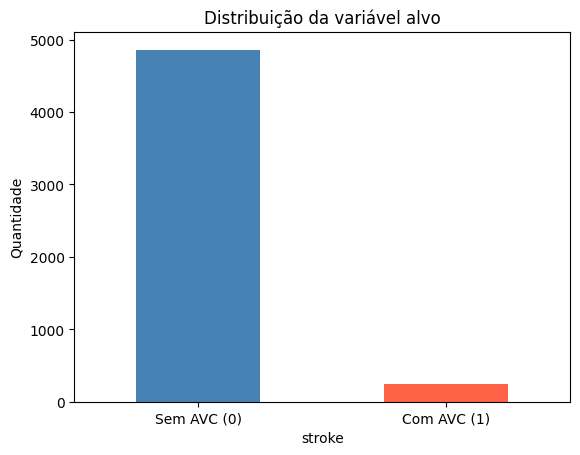

In [9]:
print(df['stroke'].value_counts())  # quantidade de pacientes com e sem AVC
print(df['stroke'].value_counts(normalize=True).round(3))  # proporção de cada classe

df['stroke'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])  # gráfico de barras das classes

plt.xticks([0, 1], ['Sem AVC (0)', 'Com AVC (1)'], rotation=0)  # nomes legíveis no eixo x
plt.title('Distribuição da variável alvo')  # título do gráfico
plt.ylabel('Quantidade')  # rótulo do eixo y
plt.show()  # exibe o gráfico

O dataset é **muito desbalanceado** (~95% sem AVC). Um modelo que chutasse sempre "sem AVC" teria ~95% de acurácia e seria inútil. Por isso:
- usamos `class_weight='balanced'` no SVC (erros na classe rara pesam mais);
- otimizamos pela métrica **F1**, que considera precisão e recall da classe positiva;
- usamos divisão **estratificada**.

## 7. Separação entre variáveis e alvo + treino/teste

In [10]:
X = df.drop(columns=['stroke'])  # variáveis explicativas (tudo menos o alvo)

y = df['stroke']  # variável alvo (0 = sem AVC, 1 = com AVC)

# divide os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,  # dados de entrada e alvo
    test_size=0.2,  # 20% para teste, 80% para treino
    stratify=y,  # mantém a mesma proporção de AVC nos dois conjuntos
    random_state=42  # semente para resultados reprodutíveis
)  # fim da divisão

print('Treino:', X_train.shape, '| Teste:', X_test.shape)  # mostra o tamanho de cada conjunto

Treino: (4087, 10) | Teste: (1022, 10)


## 8. Pré-processamento: tratamento de N/A, normalização e encode

Separamos as colunas em três grupos:
- **Numéricas contínuas** → imputação pela mediana + `StandardScaler`
- **Binárias já numéricas** (`hypertension`, `heart_disease`, já em 0/1) → só imputação por segurança
- **Categóricas (texto)** → imputação pela moda + `OneHotEncoder`

In [12]:
colunas_numericas = ['age', 'avg_glucose_level', 'bmi']  # variáveis contínuas
colunas_binarias = ['hypertension', 'heart_disease']  # variáveis que já estão codificadas como 0/1
colunas_categoricas = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']  # variáveis de texto

pipeline_numerico = Pipeline(steps=[  # sequência de passos para as colunas numéricas
    ('imputador', SimpleImputer(strategy='median')),  # preenche N/A (ex.: bmi) com a mediana do treino
    ('normalizador', StandardScaler())  # deixa cada coluna com média 0 e desvio padrão 1
])  # fim do pipeline numérico

pipeline_categorico = Pipeline(steps=[  # sequência de passos para as colunas categóricas
    ('imputador', SimpleImputer(strategy='most_frequent')),  # preenche eventuais N/A com a categoria mais comum
    ('encoder', OneHotEncoder(handle_unknown='ignore'))  # cria uma coluna 0/1 por categoria; ignora categorias novas no teste
])  # fim do pipeline categórico

preprocessador = ColumnTransformer(transformers=[  # junta os tratamentos, cada um aplicado ao seu grupo de colunas
    ('num', pipeline_numerico, colunas_numericas),  # aplica o pipeline numérico às colunas contínuas
    ('bin', SimpleImputer(strategy='most_frequent'), colunas_binarias),  # binárias: apenas garante que não haja N/A
    ('cat', pipeline_categorico, colunas_categoricas)  # aplica o pipeline categórico às colunas de texto
], sparse_threshold=0)  # força a saída como matriz densa (numpy)

Conferindo o resultado do pré-processamento (apenas para inspeção — o treino real será feito no Pipeline):

In [13]:
X_train_transformado = preprocessador.fit_transform(X_train)  # aprende e aplica o pré-processamento no treino

print('Formato após o pré-processamento:', X_train_transformado.shape)  # colunas aumentam por causa do one-hot
print('Ainda existe algum N/A?', np.isnan(X_train_transformado).any())  # deve ser False

nomes_colunas = preprocessador.get_feature_names_out()  # recupera os nomes das novas colunas
pd.DataFrame(X_train_transformado, columns=nomes_colunas).head()  # mostra as primeiras linhas já tratadas

Formato após o pré-processamento: (4087, 20)
Ainda existe algum N/A? False


,num__age,num__avg_glucose_level,num__bmi,bin__hypertension,bin__heart_disease,cat__gender_Female,cat__gender_Male,cat__ever_married_No,cat__ever_married_Yes,cat__work_type_Govt_job,cat__work_type_Never_worked,cat__work_type_Private,cat__work_type_Self-employed,cat__work_type_children,cat__Residence_type_Rural,cat__Residence_type_Urban,cat__smoking_status_Unknown,cat__smoking_status_formerly smoked,cat__smoking_status_never smoked,cat__smoking_status_smokes
0,0.209397,-0.821221,0.549234,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,-0.629845,-0.485884,-0.988900,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,-0.364822,0.302317,-0.769166,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,-0.232310,0.062342,0.497532,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,-1.292405,-0.527297,0.355351,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


## 9. Modelo base (SVC sem ajuste) — referência para comparação

In [14]:
modelo_base = Pipeline(steps=[  # pipeline com pré-processamento + SVC padrão
    ('prep', preprocessador),  # etapa de pré-processamento
    ('svc', SVC(class_weight='balanced', random_state=42))  # SVC com hiperparâmetros padrão
])  # fim do pipeline

modelo_base.fit(X_train, y_train)  # treina o modelo base

f1_base = f1_score(y_test, modelo_base.predict(X_test))  # calcula o F1 no conjunto de teste

print('F1 do SVC padrão no teste:', round(f1_base, 4))  # exibe o resultado

F1 do SVC padrão no teste: 0.2018


## 10. GridSearchCV

Hiperparâmetros testados:
- **`kernel`**: `linear` (fronteira reta) ou `rbf` (fronteira curva);
- **`C`**: penalização dos erros. C pequeno = margem larga e modelo mais simples; C grande = tenta acertar tudo (risco de overfitting);
- **`gamma`** (só no RBF): alcance da influência de cada ponto. Gamma alto = fronteira muito recortada.

Usamos duas grades separadas para não testar `gamma` à toa com o kernel linear (onde ele não tem efeito).

In [22]:
# Cria um pipeline com pré-processamento e classificação
modelo = Pipeline(steps=[
    ('prep', preprocessador),
    ('svc', SVC(class_weight='balanced', random_state=42))
])

# Define os hiperparâmetros que serão testados
param_grid = [
    # Testa o SVC com kernel linear
    {
        'svc__kernel': ['linear'],
        'svc__C': [0.01, 0.1, 1, 10]
    },

    # Testa o SVC com kernel RBF
    {
        'svc__kernel': ['rbf'],
        'svc__C': [0.1, 1, 10, 100],
        'svc__gamma': ['scale', 0.01, 0.1, 1]
    }
]

# Divide os dados em 5 partes para a validação cruzada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Configura a busca pelos melhores hiperparâmetros
grid = GridSearchCV(
    estimator=modelo,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Executa a busca utilizando os dados de treinamento
grid.fit(X_train, y_train)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(sparse_threshold=0,
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('imputador',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('normalizador',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'avg_glucose_level',
                                                                          'bmi']),
                                                                        ('bin',
                                                                         SimpleImputer(strategy='most_frequent'),
                                                                         ['hy...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['gender',
                                                                          'ever_married',
                                                                          'work_type',
                                                                          'Residence_type',
                                                                          'smoking_status'])])),
                                       ('svc',
                                        SVC(class_weight='balanced',
                                            random_state=42))]),
             n_jobs=-1,
             param_grid=[{'svc__C': [0.01, 0.1, 1, 10],
                          'svc__kernel': ['linear']},
                         {'svc__C': [0.1, 1, 10, 100],
                          'svc__gamma': ['scale', 0.01, 0.1, 1],
                          'svc__kernel': ['rbf']}],
             scoring='f1', verbose=1)

## 11. Resultados da busca

In [16]:
print('Melhores hiperparâmetros:', grid.best_params_)  # combinação vencedora
print('Melhor F1 médio na validação cruzada:', round(grid.best_score_, 4))  # desempenho médio dela nos folds

Melhores hiperparâmetros: {'svc__C': 1, 'svc__kernel': 'linear'}
Melhor F1 médio na validação cruzada: 0.2263


In [17]:
resultados = pd.DataFrame(grid.cv_results_)  # transforma os resultados de todas as combinações em tabela
resultados = resultados[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]  # mantém só as colunas úteis
resultados.sort_values('rank_test_score').head(10)  # mostra as 10 melhores combinações

,params,mean_test_score,std_test_score,rank_test_score
2,"{'svc__C': 1, 'svc__kernel': 'linear'}",0.226348,0.019352,1
3,"{'svc__C': 10, 'svc__kernel': 'linear'}",0.225989,0.018973,2
1,"{'svc__C': 0.1, 'svc__kernel': 'linear'}",0.225420,0.019320,3
13,"{'svc__C': 10, 'svc__gamma': 0.01, 'svc__kerne...",0.222992,0.017703,4
10,"{'svc__C': 1, 'svc__gamma': 0.1, 'svc__kernel'...",0.221718,0.018653,5
4,"{'svc__C': 0.1, 'svc__gamma': 'scale', 'svc__k...",0.220444,0.017893,6
6,"{'svc__C': 0.1, 'svc__gamma': 0.1, 'svc__kerne...",0.220198,0.019513,7
0,"{'svc__C': 0.01, 'svc__kernel': 'linear'}",0.220040,0.014779,8
9,"{'svc__C': 1, 'svc__gamma': 0.01, 'svc__kernel...",0.219982,0.017744,9
17,"{'svc__C': 100, 'svc__gamma': 0.01, 'svc__kern...",0.215115,0.016443,10


## 12. Avaliação final no conjunto de teste

In [18]:
melhor_modelo = grid.best_estimator_  # pipeline já re-treinado com os melhores parâmetros em todo o treino

y_pred = melhor_modelo.predict(X_test)  # faz previsões em dados nunca vistos

print(classification_report(y_test, y_pred, target_names=['Sem AVC', 'Com AVC']))  # precisão, recall e F1 por classe

              precision    recall  f1-score   support

     Sem AVC       0.99      0.71      0.83       972
     Com AVC       0.13      0.82      0.22        50

    accuracy                           0.72      1022
   macro avg       0.56      0.77      0.53      1022
weighted avg       0.95      0.72      0.80      1022



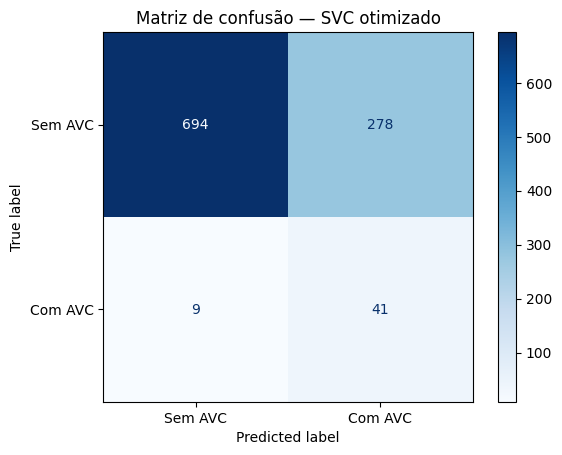

In [19]:
ConfusionMatrixDisplay.from_predictions(  # plota a matriz de confusão
    y_test, y_pred,  # valores reais e previstos
    display_labels=['Sem AVC', 'Com AVC'],  # nomes das classes
    cmap='Blues'  # esquema de cores
)  # fim da chamada

plt.title('Matriz de confusão — SVC otimizado')  # título do gráfico

plt.show()  # exibe o gráfico

In [20]:
f1_otimizado = f1_score(y_test, y_pred)  # F1 do modelo otimizado no teste

print('F1 SVC padrão   :', round(f1_base, 4))  # resultado sem ajuste
print('F1 SVC otimizado:', round(f1_otimizado, 4))  # resultado com GridSearchCV

F1 SVC padrão   : 0.2018
F1 SVC otimizado: 0.2222


## 13. Conclusão

- **Duplicidade:** removemos o `id` e verificamos linhas repetidas antes de modelar.
- **N/A:** os valores ausentes de `bmi` foram imputados pela mediana; `Unknown` em `smoking_status` foi mantido como categoria.
- **Categóricos:** convertidos com One-Hot Encoding; a categoria rara `Other` foi removida.
- **Normalização:** `StandardScaler` nas variáveis contínuas — essencial para o SVC, que depende de distâncias.
- **Sem vazamento:** todo o pré-processamento ficou dentro do `Pipeline`, ajustado apenas no treino de cada fold.
- **GridSearchCV:** testou 20 combinações de `kernel`, `C` e `gamma` com validação cruzada estratificada, otimizando o F1.

Como o dataset é muito desbalanceado e prever AVC é naturalmente difícil, o F1 da classe positiva tende a ser modesto. O modelo prioriza **recall** (encontrar os casos de AVC) em troca de mais falsos positivos — o que faz sentido em um contexto de triagem médica, onde deixar passar um caso real é mais grave que um alarme falso.